# Mini Project — Exploratory Data Analysis on the Early 2019-nCoV Outbreak

**Student:** Advik Singh  
**Registration Number:** Ra2411056030023

**Goal:** Uncover country-wise and province-wise trends, recovery rates, and the first international spillover of the 2019 novel coronavirus, using nothing but the tools from Module 1: NumPy, Pandas, and Matplotlib/Seaborn.

**Data source** (local CSV, no extra download needed):
- **Case data:** `2019_nC0v_20200121_20200126 - SUMMARY.csv` — aggregated Johns Hopkins CSSE daily situation reports covering **21–26 January 2020**.
- Columns: `Province/State`, `Country`, `Date last updated`, `Confirmed`, `Suspected`, `Recovered`, `Deaths`.

**Workflow:** Load → Inspect → Clean → Explore (groupby/pivot) → Visualise (12 charts) → Summarise findings.

> **Note on the data window:** this file is an *early-outbreak* snapshot. Vaccines did not exist yet, testing was limited, and almost every confirmed case sat inside Mainland China — especially Hubei province. The interesting story is how fast the counts grew in six days, and which other countries had already reported imported cases.


## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

DATA_FILE = "2019_nC0v_20200121_20200126 - SUMMARY.csv"
print("Ready.")


Ready.


## 2. Load the Data

We read the summary CSV with `pd.read_csv()` — exactly the File I/O skill from Module 1. The file name has spaces, so we keep it in quotes.


In [2]:
raw = pd.read_csv(DATA_FILE)

print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
raw.head()


Shape: (416, 7)
Columns: ['Province/State', 'Country', 'Date last updated', 'Confirmed', 'Suspected', 'Recovered', 'Deaths']


,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Anhui,Mainland China,1/21/2020 10pm,NaN,3.0,NaN,NaN
1,Beijing,Mainland China,1/21/2020 10pm,10.0,NaN,NaN,NaN
2,Chongqing,Mainland China,1/21/2020 10pm,5.0,NaN,NaN,NaN
3,Guangdong,Mainland China,1/21/2020 10pm,17.0,4.0,NaN,NaN
4,Guangxi,Mainland China,1/21/2020 10pm,NaN,1.0,NaN,NaN


## 3. Inspect Before Touching Anything

Always check shape, dtypes, and missing values first — this tells you exactly what cleaning is needed.


In [3]:
raw.dtypes


Province/State           str
Country                  str
Date last updated        str
Confirmed            float64
Suspected            float64
Recovered            float64
Deaths               float64
dtype: object

In [4]:
raw.isna().sum()


Province/State        73
Country                0
Date last updated      0
Confirmed             29
Suspected            328
Recovered            370
Deaths               385
dtype: int64

In [5]:
print("Number of unique country names:", raw["Country"].nunique())
sorted(raw["Country"].unique())


Number of unique country names: 20


['Australia',
 'Brazil',
 'Canada',
 'Colombia',
 'France',
 'Hong Kong',
 'Japan',
 'Macau',
 'Mainland China',
 'Malaysia',
 'Malaysia ',
 'Mexico',
 'Nepal',
 'Philippines',
 'Singapore ',
 'South Korea',
 'Taiwan',
 'Thailand',
 'US',
 'Vietnam']

In [6]:
print("Number of unique Province/State values:", raw["Province/State"].nunique(dropna=True))
raw["Date last updated"].unique()[:12]


Number of unique Province/State values: 40


<StringArray>
[ '1/21/2020 10pm',   '1/22/20 12:00',   '1/23/20 12:00', '1/24/2020  12am',
 '1/24/2020  12pm',  '1/24/2020  4pm', '1/25/2020  12am', '1/25/2020  12pm',
 '1/25/2020  10pm',   '1/26/20 11:00',   '1/26/20 16:30',   '1/26/20 23:00']
Length: 12, dtype: str

Several problems jump out immediately:

1. **Numeric columns have missing values** — empty cells in `Confirmed`, `Suspected`, `Recovered`, and `Deaths` mean "not reported", which we should treat as 0 for counts.
2. **Country names are messy**: `Singapore ` and `Malaysia ` have trailing spaces, so they would be counted as different countries if we group naively.
3. **`Province/State` is blank** for countries that report nationally (Thailand, Japan, France, …).
4. **Dates are stored as text** in mixed formats (`1/21/2020 10pm`, `1/22/20 12:00`, `1/24/2020  12am`).
5. Some early rows list **Brazil / Mexico / Colombia / Philippines with no confirmed cases** — they appear because they were being *watched*, not because they had an outbreak yet.

This is exactly the kind of real-world messiness we fix *before* doing any analysis, never after.


## 4. Clean the Data


In [7]:
df = raw.copy()

# Rename to clean, snake_case column names
df.columns = [
    "province", "country", "last_update",
    "confirmed", "suspected", "recovered", "deaths",
]

# Strip whitespace from names
df["country"] = df["country"].astype(str).str.strip()
df["province"] = df["province"].fillna("").astype(str).str.strip()

# Harmonise a couple of country aliases
df["country"] = df["country"].replace({"China": "Mainland China"})

# Fix data types — missing counts become 0
for col in ["confirmed", "suspected", "recovered", "deaths"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Mixed timestamp formats (12am / 10pm / 23:00) parse with format="mixed"
df["last_update"] = pd.to_datetime(df["last_update"], format="mixed")
df["date"] = df["last_update"].dt.normalize()

# A readable location label, plus a China flag
df["location"] = np.where(df["province"] != "", df["province"] + ", " + df["country"], df["country"])
df["is_china"] = df["country"].eq("Mainland China")

# Derived column: active cases = confirmed - deaths - recovered
df["active"] = (df["confirmed"] - df["deaths"] - df["recovered"]).clip(lower=0)

df = df.sort_values(["date", "last_update", "country", "province"]).reset_index(drop=True)

print("Rows:", len(df))
print("Countries after cleaning:", df["country"].nunique())
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
df.dtypes


Rows: 416
Countries after cleaning: 19
Date range: 2020-01-21 → 2020-01-26


province                  str
country                   str
last_update    datetime64[us]
confirmed               int64
suspected               int64
recovered               int64
deaths                  int64
date           datetime64[us]
location                  str
is_china                 bool
active                  int64
dtype: object

In [8]:
df.isna().sum().sum()   # should be 0 — fully clean now


np.int64(0)

In [9]:
print("Clean country list:")
sorted(df["country"].unique())


Clean country list:


['Australia',
 'Brazil',
 'Canada',
 'Colombia',
 'France',
 'Hong Kong',
 'Japan',
 'Macau',
 'Mainland China',
 'Malaysia',
 'Mexico',
 'Nepal',
 'Philippines',
 'Singapore',
 'South Korea',
 'Taiwan',
 'Thailand',
 'US',
 'Vietnam']

## 5. Global-Level Summary (groupby)

The CSV is a stack of situation reports, so the same province appears many times. For a fair daily total we take the **last report of each location on each calendar day**, then `groupby` the date.


In [10]:
def last_snapshot(frame):
    """Keep the latest report for every province/country pair."""
    return (
        frame.sort_values("last_update")
             .drop_duplicates(["province", "country"], keep="last")
    )

daily_rows = []
for day, group in df.groupby("date"):
    last = last_snapshot(group)
    daily_rows.append({
        "date": day,
        "confirmed": int(last["confirmed"].sum()),
        "deaths": int(last["deaths"].sum()),
        "recovered": int(last["recovered"].sum()),
        "suspected": int(last["suspected"].sum()),
        "active": int(last["active"].sum()),
        "locations": int(len(last)),
        "countries": int(last["country"].nunique()),
        "china_confirmed": int(last.loc[last["is_china"], "confirmed"].sum()),
        "row_confirmed": int(last.loc[~last["is_china"], "confirmed"].sum()),
    })

daily = pd.DataFrame(daily_rows)
daily["new_confirmed"] = daily["confirmed"].diff().fillna(daily["confirmed"]).astype(int)
daily["recovery_rate"] = (daily["recovered"] / daily["confirmed"] * 100).round(2)
daily["death_rate"] = (daily["deaths"] / daily["confirmed"] * 100).round(2)
daily


,date,confirmed,deaths,recovered,suspected,active,locations,countries,china_confirmed,row_confirmed,new_confirmed,recovery_rate,death_rate
0,2020-01-21,332,6,25,169,301,27,7,326,6,332,7.53,1.81
1,2020-01-22,555,17,28,137,510,38,8,547,8,223,5.05,3.06
2,2020-01-23,653,18,30,144,605,46,16,639,14,98,4.59,2.76
3,2020-01-24,941,26,36,159,879,41,11,916,25,288,3.83,2.76
4,2020-01-25,1820,54,49,404,1717,44,14,1781,39,879,2.69,2.97
5,2020-01-26,2794,80,54,0,2660,47,15,2737,57,974,1.93,2.86


In [11]:
latest_date = df["date"].max()
latest_row = daily.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['recovered']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Suspected       : {latest_row['suspected']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")
print(f"  Countries       : {latest_row['countries']}")


As of 2020-01-26:
  Total confirmed : 2,794
  Total recovered : 54
  Total deaths    : 80
  Suspected       : 0
  Recovery rate   : 1.93%
  Death rate      : 2.86%
  Countries       : 15


## 6. Country / Province Snapshot (latest date)

**pivot_table**: confirmed cases by country and date, so we can see when each country's count moved.


In [12]:
latest = last_snapshot(df[df["date"] == latest_date]).copy()
latest["recovery_rate"] = np.where(
    latest["confirmed"] > 0,
    (latest["recovered"] / latest["confirmed"] * 100).round(2),
    0,
)
latest["death_rate"] = np.where(
    latest["confirmed"] > 0,
    (latest["deaths"] / latest["confirmed"] * 100).round(2),
    0,
)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)
top10[["location", "confirmed", "deaths", "recovered", "recovery_rate", "death_rate"]]


,location,confirmed,deaths,recovered,recovery_rate,death_rate
0,"Hubei, Mainland China",1423,76,44,3.09,5.34
1,"Guangdong, Mainland China",146,0,2,1.37,0.00
2,"Zhejiang, Mainland China",128,0,1,0.78,0.00
3,"Henan, Mainland China",128,1,0,0.00,0.78
4,"Chongqing, Mainland China",110,0,0,0.00,0.00
5,"Hunan, Mainland China",100,0,0,0.00,0.00
6,"Anhui, Mainland China",70,0,0,0.00,0.00
7,"Sichuan, Mainland China",69,0,0,0.00,0.00
8,"Beijing, Mainland China",68,0,2,2.94,0.00
9,"Shandong, Mainland China",63,0,0,0.00,0.00


In [13]:
by_country = (
    latest.groupby("country", as_index=False)[["confirmed", "deaths", "recovered"]]
          .sum()
          .sort_values("confirmed", ascending=False)
)
by_country


,country,confirmed,deaths,recovered
6,Mainland China,2737,80,51
3,Hong Kong,8,0,0
12,Thailand,8,0,2
5,Macau,6,0,0
13,US,5,0,0
0,Australia,4,0,0
4,Japan,4,0,1
11,Taiwan,4,0,0
9,Singapore,4,0,0
7,Malaysia,4,0,0


In [14]:
# Confirmed cases by country × date (locations outside Mainland China stay visible)
country_day = (
    df.sort_values("last_update")
      .drop_duplicates(["date", "province", "country"], keep="last")
)

pivot = country_day.pivot_table(
    values="confirmed",
    index="country",
    columns="date",
    aggfunc="sum",
    fill_value=0,
)
pivot.loc[by_country["country"].head(8)].rename(
    columns=lambda d: d.strftime("%Y-%m-%d")
)


date,2020-01-21,2020-01-22,2020-01-23,2020-01-24,2020-01-25,2020-01-26
country,,,,,,
Mainland China,326,547,639,916,1776,2737
Hong Kong,0,0,2,2,5,8
Thailand,2,2,3,5,7,8
Macau,0,1,2,2,2,6
US,1,1,1,2,2,5
Australia,0,0,0,0,4,4
Japan,1,2,1,2,2,4
Taiwan,1,1,1,3,3,4


## 7. Visualisations (12 charts)

We'll work through global trends, Hubei's dominance, and the first international cases — using both Matplotlib and Seaborn, matching the Module 1 handbook patterns.


### Chart 1 — Global cumulative trend


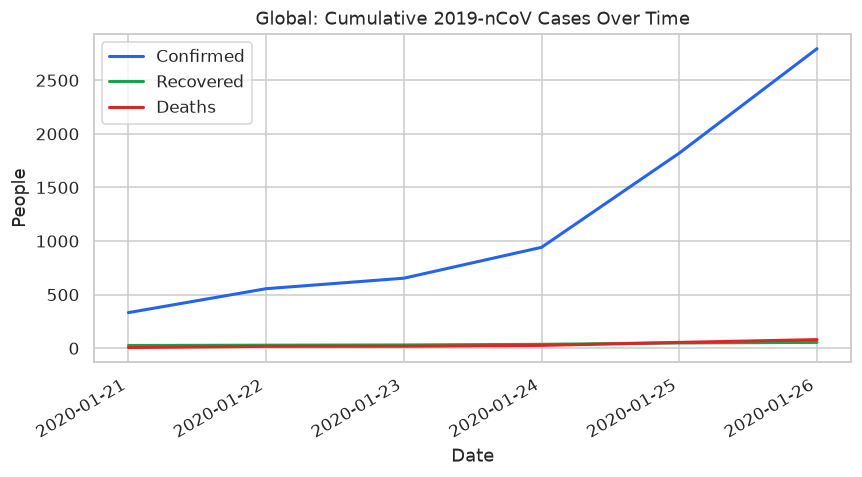

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(daily["date"], daily["confirmed"], label="Confirmed", color="#2563eb", lw=2)
ax.plot(daily["date"], daily["recovered"], label="Recovered", color="#16a34a", lw=2)
ax.plot(daily["date"], daily["deaths"], label="Deaths", color="#dc2626", lw=2)
ax.set_title("Global: Cumulative 2019-nCoV Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Chart 2 — Daily new confirmed cases


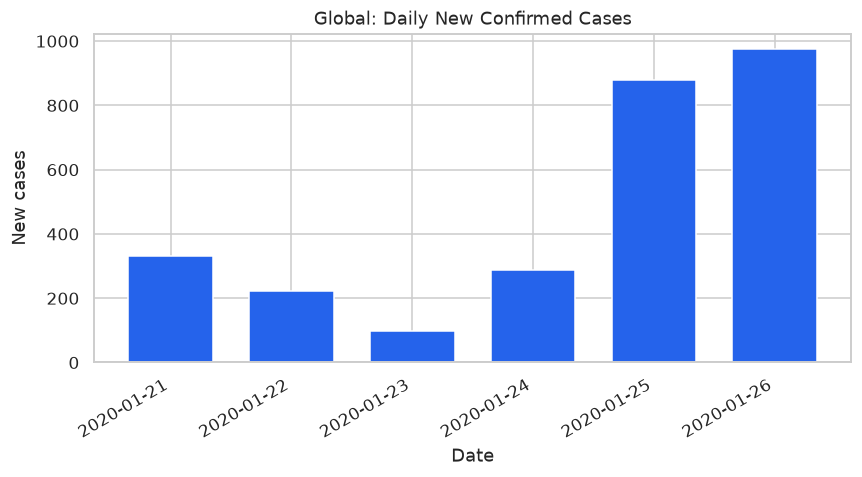

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(daily["date"], daily["new_confirmed"], color="#2563eb", width=0.7)
ax.set_title("Global: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Chart 3 — Top 10 locations by total confirmed cases


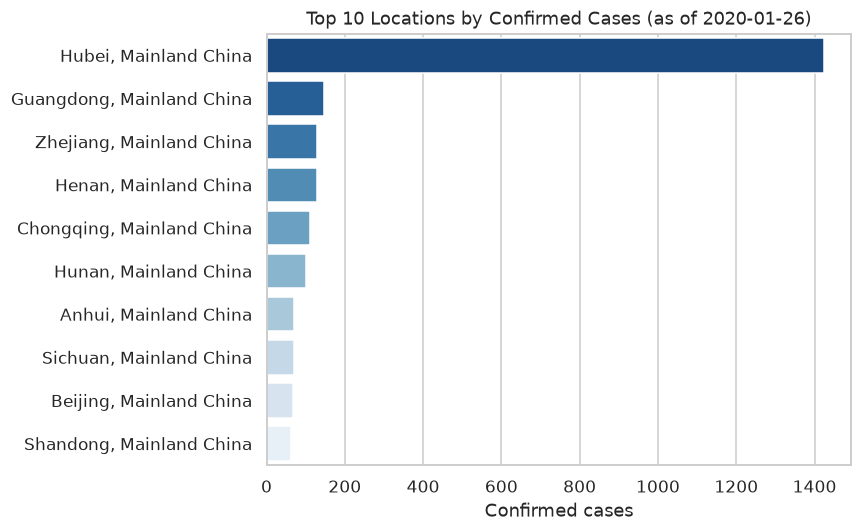

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="location", x="confirmed", hue="location",
            palette="Blues_r", legend=False, ax=ax)
ax.set_title(f"Top 10 Locations by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Chart 4 — Recovery rate of the 10 worst-hit locations


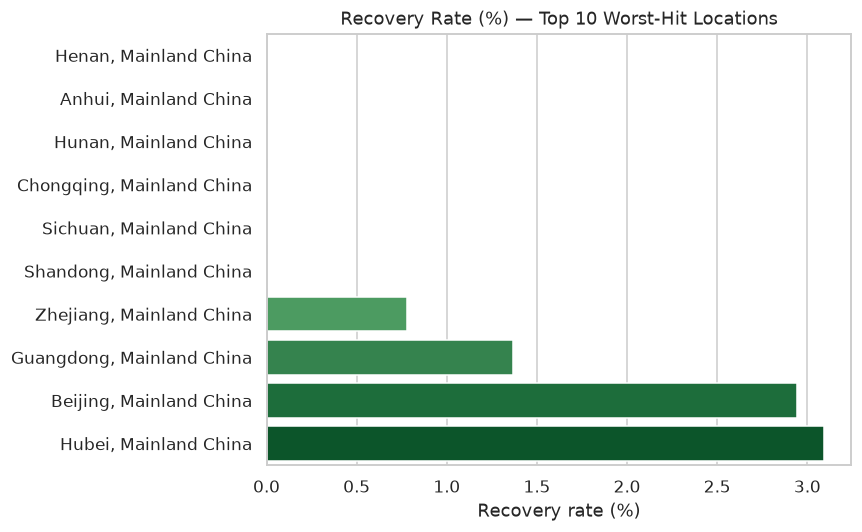

In [18]:
top10_sorted = top10.sort_values("recovery_rate")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_sorted, y="location", x="recovery_rate", hue="location",
            palette="Greens", legend=False, ax=ax)
ax.set_title("Recovery Rate (%) — Top 10 Worst-Hit Locations")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Chart 5 — Confirmed-case trend for the top 5 locations


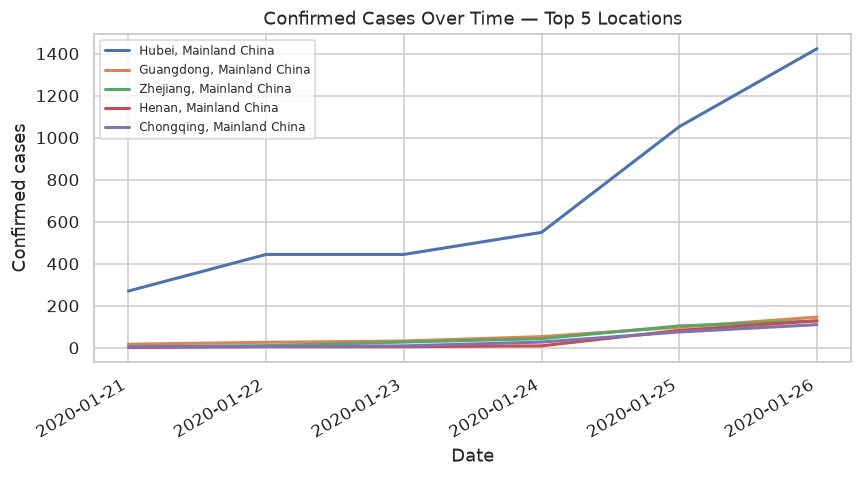

In [19]:
top5_locations = top10["location"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for loc in top5_locations:
    sub = (df[df["location"] == loc]
           .sort_values("last_update")
           .drop_duplicates("date", keep="last"))
    ax.plot(sub["date"], sub["confirmed"], label=loc, lw=2)
ax.set_title("Confirmed Cases Over Time — Top 5 Locations")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Chart 6 — Share of global cases (pie)


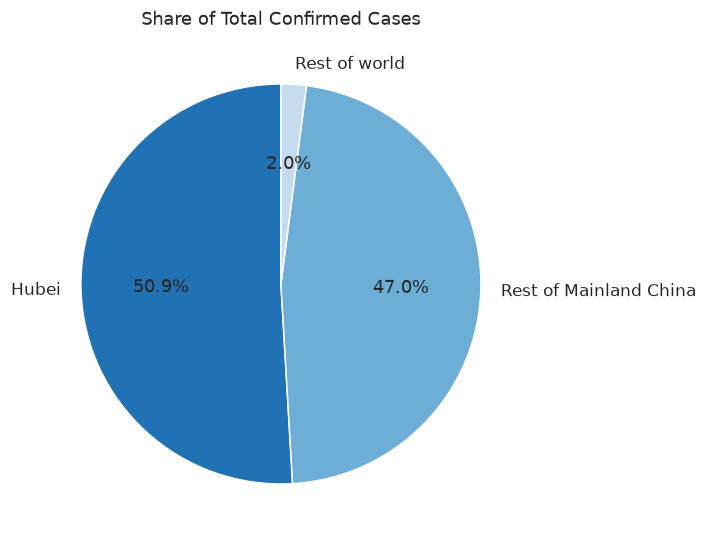

In [20]:
hubei = int(latest.loc[latest["province"] == "Hubei", "confirmed"].sum())
other_china = int(latest.loc[latest["is_china"] & (latest["province"] != "Hubei"), "confirmed"].sum())
rest = int(latest.loc[~latest["is_china"], "confirmed"].sum())

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(
    [hubei, other_china, rest],
    labels=["Hubei", "Rest of Mainland China", "Rest of world"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Blues_r", 3),
)
ax.set_title("Share of Total Confirmed Cases")
plt.tight_layout()
plt.show()


### Chart 7 — Global recovery-rate vs death-rate trend


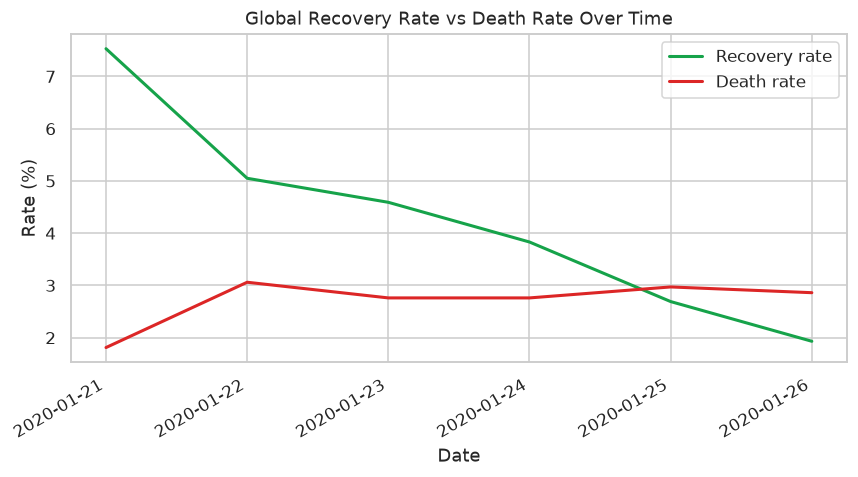

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(daily["date"], daily["recovery_rate"], color="#16a34a", lw=2, label="Recovery rate")
ax.plot(daily["date"], daily["death_rate"], color="#dc2626", lw=2, label="Death rate")
ax.set_title("Global Recovery Rate vs Death Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Rate (%)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Chart 8 — Deaths vs confirmed cases by location (bubble = case count)


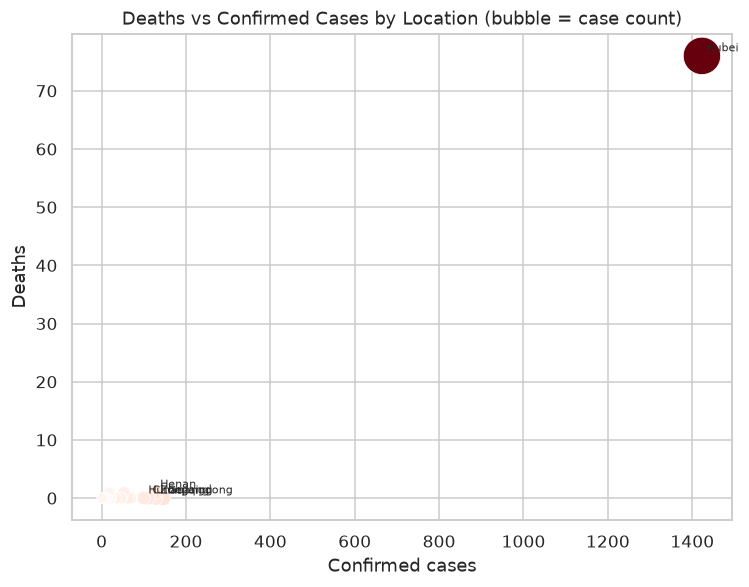

In [22]:
sizeable = latest[latest["confirmed"] >= 1]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="confirmed", y="deaths", size="confirmed",
                sizes=(40, 600), hue="confirmed", palette="Reds", legend=False, ax=ax)
for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["location"].split(",")[0], (r["confirmed"], r["deaths"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_title("Deaths vs Confirmed Cases by Location (bubble = case count)")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("Deaths")
plt.tight_layout()
plt.show()


### Chart 9 — Correlation heatmap of global metrics


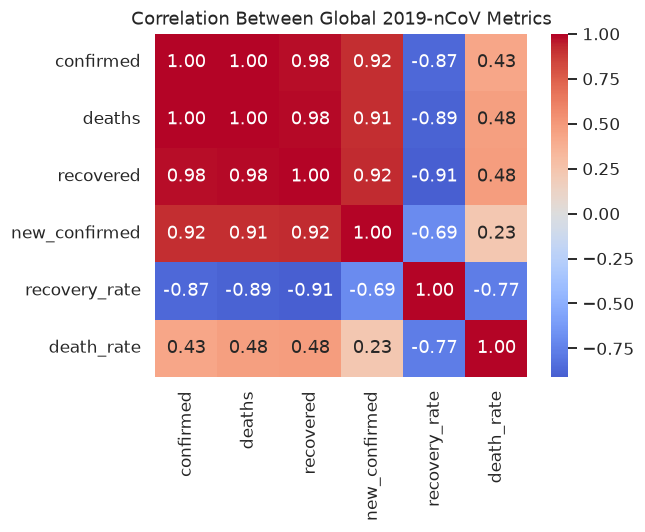

In [23]:
corr_cols = ["confirmed", "deaths", "recovered", "new_confirmed", "recovery_rate", "death_rate"]
corr = daily[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between Global 2019-nCoV Metrics")
plt.tight_layout()
plt.show()


### Chart 10 — Spread of location-level confirmed counts, by day (boxplot)


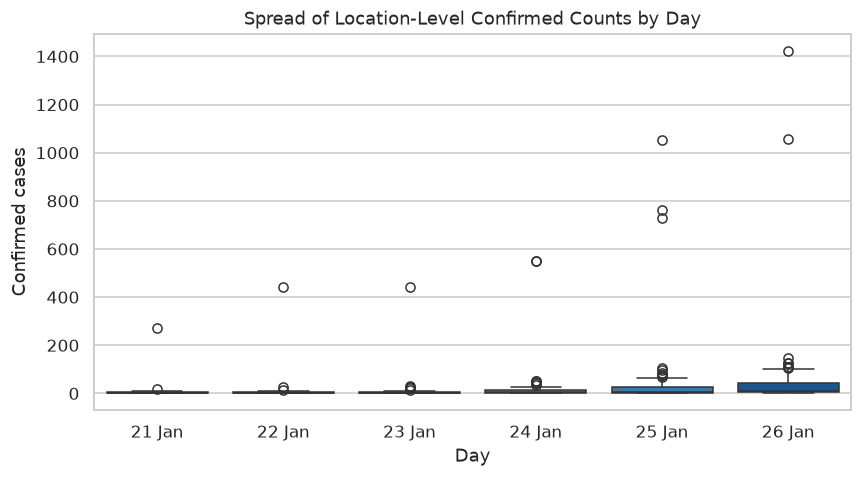

In [24]:
box = df.copy()
box["day"] = box["date"].dt.strftime("%d Jan")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=box[box["confirmed"] > 0], x="day", y="confirmed",
            hue="day", palette="Blues", legend=False, ax=ax)
ax.set_title("Spread of Location-Level Confirmed Counts by Day")
ax.set_xlabel("Day"); ax.set_ylabel("Confirmed cases")
plt.tight_layout()
plt.show()


### Chart 11 — Mainland China vs the rest of the world


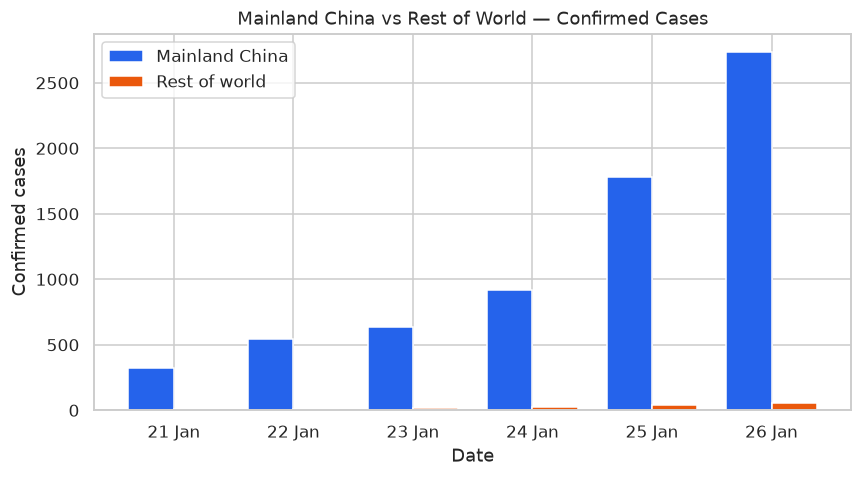

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(daily))
w = 0.38
ax.bar(x - w/2, daily["china_confirmed"], width=w, color="#2563eb", label="Mainland China")
ax.bar(x + w/2, daily["row_confirmed"], width=w, color="#ea580c", label="Rest of world")
ax.set_xticks(x, [d.strftime("%d Jan") for d in daily["date"]])
ax.set_title("Mainland China vs Rest of World — Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend()
plt.tight_layout()
plt.show()


### Chart 12 — International cases outside Mainland China


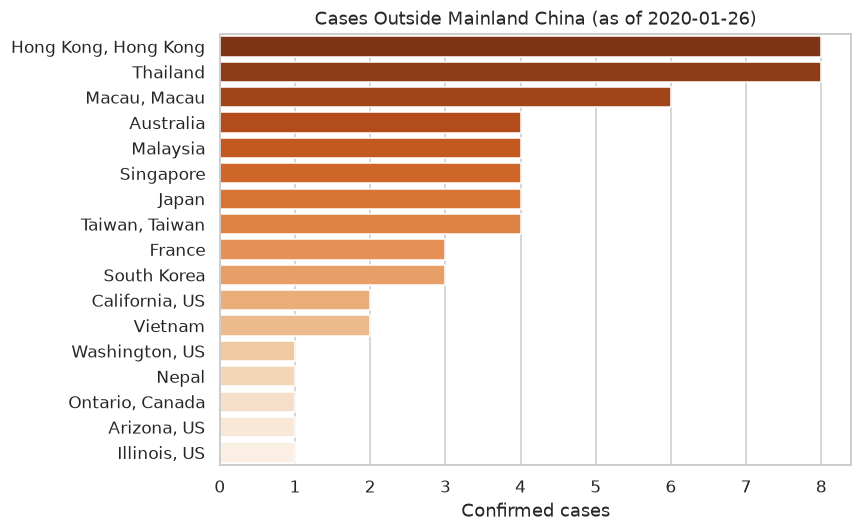

In [26]:
intl = latest[~latest["is_china"]].sort_values("confirmed", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=intl, y="location", x="confirmed", hue="location",
            palette="Oranges_r", legend=False, ax=ax)
ax.set_title(f"Cases Outside Mainland China (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 8. Save the Cleaned Dataset

One more File I/O practice rep — save the cleaned table so it can be reused without repeating the cleaning steps.


In [27]:
df.to_csv("cleaned_ncov_summary.csv", index=False)
print("Saved cleaned_ncov_summary.csv —", df.shape[0], "rows.")


Saved cleaned_ncov_summary.csv — 416 rows.


## 9. Written Summary

**Coverage.** The dataset stacks Johns Hopkins CSSE situation reports from **21 January 2020 to 26 January 2020** — the first six published days of the 2019-nCoV outbreak. After cleaning trailing spaces and missing counts, we have reports for **19 countries** and about **40 Chinese provinces / administrative regions**.

**Global picture.** Confirmed cases rose from **332** on 21 January to **2,794** on 26 January — roughly an **8×** jump in six days. Recoveries lagged far behind (**54** people, a **1.93%** recovery rate) because almost every patient was still in hospital. Deaths rose from **6** to **80** (a **2.86%** crude death rate). Daily new cases accelerated: **+223 → +98 → +288 → +879 → +974**.

**Geographic concentration.** The outbreak was not evenly spread. **Hubei province alone held 1,423 confirmed cases (~51%)** on 26 January, and **Mainland China as a whole held 2,737 (~98%)**. Guangdong, Zhejiang, Henan, Chongqing and Hunan filled out the rest of the top six. Hubei also accounted for **76 of the 80 deaths**.

**Recovery was still tiny.** Even among the worst-hit provinces, recovery rates sat in the low single digits (Hubei ~3.1%). That is *not* a clinical failure — it is a timing effect. Six days is too short for most patients to be discharged, so the recovered column had barely started to move.

**International spillover had already started.** By 26 January, **14 countries/territories outside Mainland China** had confirmed cases, but the counts were still single-digit: Hong Kong (8), Thailand (8), Macau (6), the US (5), then Australia, Japan, Taiwan, Singapore and Malaysia on 4 each. These are imported / traveller cases, not community epidemics — yet.

**Caveats.** Early 2019-nCoV bulletins inherit every reporting quirk of a brand-new pathogen: missing numeric fields, trailing spaces in country names, mixed timestamp formats, and "watchlist" countries (Brazil, Mexico, Colombia, Philippines) that appear with **zero** confirmed cases. Recovery and death rates here are simple ratios of cumulative totals, not lag-adjusted outcome rates, so they should be read as directional trends.

**What this window cannot tell us.** India's first laboratory-confirmed case was reported on **30 January 2020**, after this file ends. Vaccination data does not exist for January 2020. The value of this EDA is the *opening chapter*: how a provincial pneumonia cluster became a multi-country outbreak in less than a week.
